In [27]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor

In [28]:
%matplotlib inline

# polar to linear

`cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR`

(540, 960, 3)


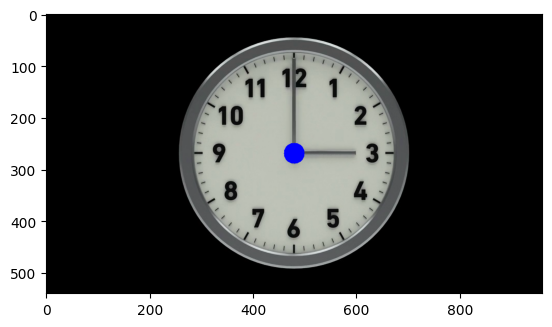

In [30]:
img  = cv2.imread("clock.jpg")
cv2.circle(img,(480,270),20,(0,0,255),-1) # top point
print(img.shape)
plt.imshow(img)

In [31]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR

(1000, 300, 3)


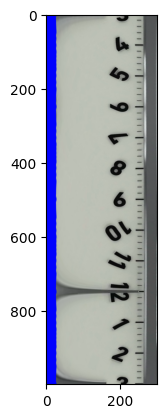

In [36]:
linear_polar_img = cv2.warpPolar(img,(300,1000),(480,270),220,flags) # w,h
print(linear_polar_img.shape)
plt.imshow(linear_polar_img)

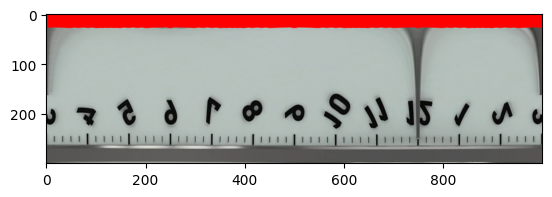

In [19]:
plt.imshow(cv2.cvtColor(linear_polar_img.transpose(1,0,2),cv2.COLOR_BGR2RGB))

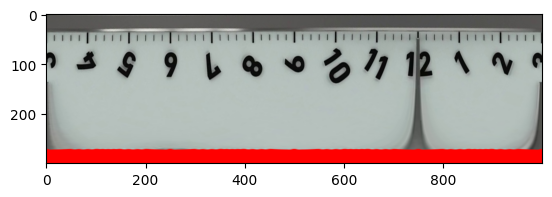

In [20]:
plt.imshow(cv2.cvtColor(linear_polar_img.transpose(1,0,2)[::-1],cv2.COLOR_BGR2RGB))

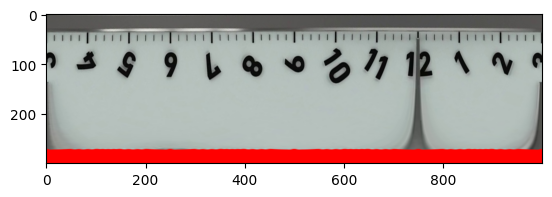

In [62]:
img  = cv2.imread("clock.jpg")
cv2.circle(img,(480,270),20,(0,0,255),-1) # top point
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
linear_polar_img = cv2.warpPolar(img,(300,1000),(480,270),220,flags) # w,h
plt.imshow(cv2.cvtColor(linear_polar_img.transpose(1,0,2)[::-1],cv2.COLOR_BGR2RGB))

# log polar

`cv.INTER_CUBIC + cv.WARP_FILL_OUTLIERS + cv.WARP_POLAR_LOG`

In [52]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LOG

In [53]:
log_polar_img = cv2.warpPolar(img,(300,1000),(480,270),220,flags)
print(log_polar_img.shape)

(1000, 300, 3)


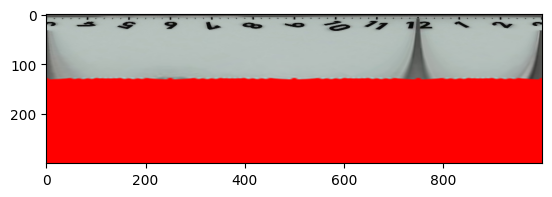

In [54]:
plt.imshow(cv2.cvtColor(log_polar_img.transpose(1,0,2)[::-1],cv2.COLOR_BGR2RGB))

# invert map

`cv.INTER_CUBIC + cv.WARP_FILL_OUTLIERS + cv.WARP_POLAR_LINEAR + cv.WARP_INVERSE_MAP`

In [55]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR + cv2.WARP_INVERSE_MAP
linear_polar_inverse_img = cv2.warpPolar(linear_polar_img,(960,540),(480,270),220,flags)

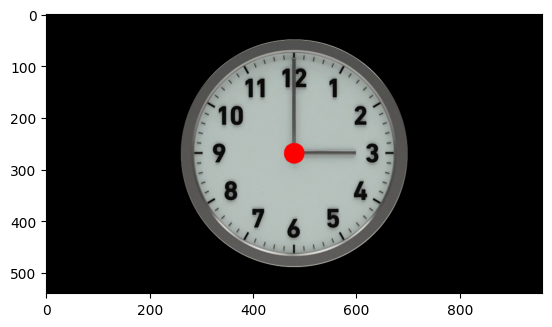

In [56]:
plt.imshow(cv2.cvtColor(linear_polar_inverse_img,cv2.COLOR_BGR2RGB))

# warp roi

(1480, 365, 3)


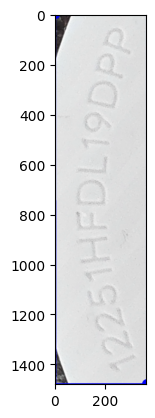

In [300]:
img = cv2.imread("img_12.jpg")
print(img.shape)
plt.imshow(img)

(365, 1480, 3)


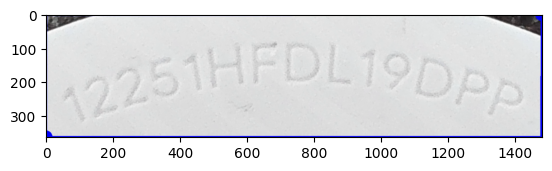

In [301]:
img = cv2.rotate(img,cv2.ROTATE_90_CLOCKWISE)
h,w,c = img.shape
print(img.shape)
plt.imshow(img)

In [302]:
r=1500 

(3000, 3000, 3)


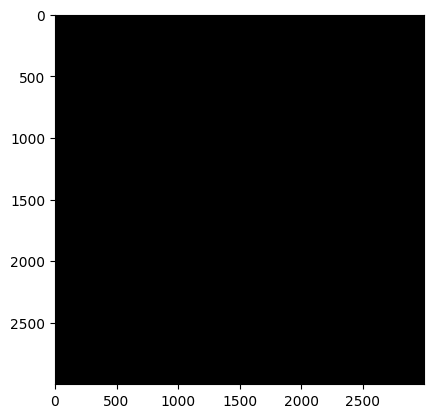

In [303]:
blank = np.zeros((r*2,r*2,3))
blank = blank.astype(np.uint8)
print(blank.shape)
plt.imshow(blank)

In [304]:
x = int(r - w/2)
y = 0
print(x)
print(y)

760
0


In [305]:
x2 = x+w
y2 = h

In [306]:
blank[y:y2,x:x2].shape

(365, 1480, 3)

In [307]:
img.shape

(365, 1480, 3)

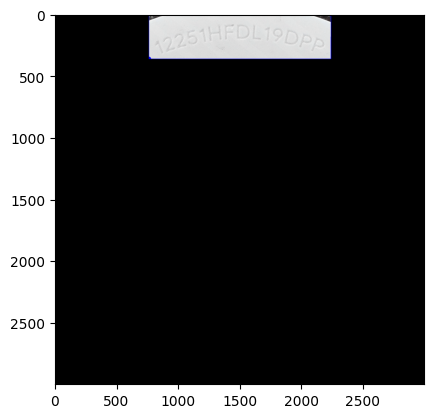

In [308]:
blank[y:y2,x:x2]=img
plt.imshow(blank)

In [309]:
blank.shape

(3000, 3000, 3)

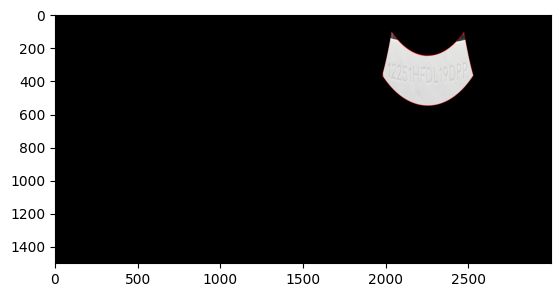

In [310]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_img = cv2.warpPolar(blank,(r,r*2),(r,r),r+300,flags) # w,h
out = polar_img.transpose(1,0,2)[::-1]
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))

In [311]:
h,w,c=out.shape

In [312]:
h_line = out[0:1,:]
print(h_line.shape)
print(np.sum(v_line))

(1, 3000, 3)
0


In [313]:
v_line = out[:,0:1]
print(v_line.shape)
print(np.sum(v_line))

(1500, 1, 3)
0


In [314]:
y_list = []
for i in range(h):
    h_line = out[i:i+1,:]
    if np.sum(h_line) != 0:
        y_list.append(i)

print(f"h0={y_list[0]},h1={y_list[-1]}")

h0=105,h1=553


In [315]:
x_list = []
for i in range(w):
    v_line = out[:,i:i+1]
    if np.sum(v_line) != 0:
        x_list.append(i)

print(f"x0={x_list[0]},x1={x_list[-1]}")

x0=1974,x1=2526


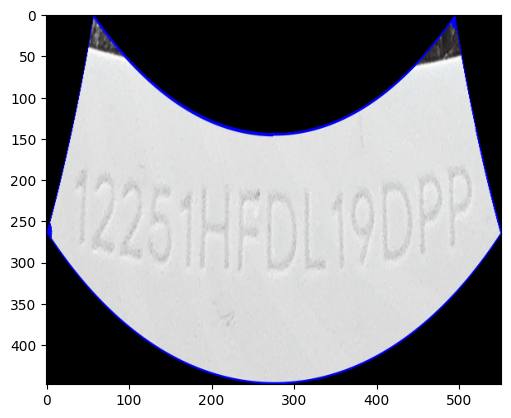

In [319]:
out = out[y_list[0]:y_list[-1],x_list[0]:x_list[-1]]
plt.imshow(out)

In [320]:
cv2.imwrite("wrapped.jpg",out)

True

# references

[cv-warpPolar-example](https://github.com/Kazuhito00/cv-warpPolar-example)